# ResNet — UV setup

Same experiments as `figures_resnet.ipynb`, but with the uv activation (`σ*(x, z) = v · σ(uᵀx)`).

In [5]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import src.spaces as spaces
spaces.SETUP = spaces.make_setup_uv()

from src.training import (
    train_resnet, loss_fn_resnet, loss_fn_fa_resnet,
    loss_fn_ea_resnet, loss_fn_da_resnet, DEFAULT_CONFIG_RESNET,
)
from src.teacher import make_wi_particles_resnet, make_arbitrary_particles_resnet
from src.metrics import rmd_to_projected
from src.utils import plot_rmd_curves, plot_uv_equivariance_resnet

import plotly.io as pio
import matplotlib.pyplot as plt

L_VALUES = [1, 10, 100, 500, 1000]  # ResNet depth
N = 3
N_REPS = 6
CONFIG = {**DEFAULT_CONFIG_RESNET, "T": 1.0, "gr": 5}
CONFIG['beta'] = 0.0

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Distance to $E^G$ — WI teacher, SI init

In [5]:
teacher_wi = make_wi_particles_resnet(1)

results_wi = {"vanilla": [], "DA": [], "FA": [], "EA": []}

for L in L_VALUES:
    for name in results_wi:
        results_wi[name].append([])

    for rep in range(N_REPS):
        key = jax.random.PRNGKey(rep * 1000 + N)

        h = train_resnet(teacher_wi, N, L, jax.random.fold_in(key, 0), CONFIG, "si")
        results_wi["vanilla"][-1].append(rmd_to_projected(h["particles"][-1][0]))

        h = train_resnet(teacher_wi, N, L, jax.random.fold_in(key, 1), CONFIG, "si", used_loss_fn=loss_fn_da_resnet)
        results_wi["DA"][-1].append(rmd_to_projected(h["particles"][-1][0]))

        h = train_resnet(teacher_wi, N, L, jax.random.fold_in(key, 2), CONFIG, "si", used_loss_fn=loss_fn_fa_resnet)
        results_wi["FA"][-1].append(rmd_to_projected(h["particles"][-1][0]))

        # h = train_resnet(teacher_wi, N, L, jax.random.fold_in(key, 3), CONFIG, "si", used_loss_fn=loss_fn_ea_resnet)
        # results_wi["EA"][-1].append(rmd_to_projected(h["particles"][-1][0]))

    print(f"L={L} done")


L=1 done
L=10 done
L=100 done
L=500 done
L=1000 done


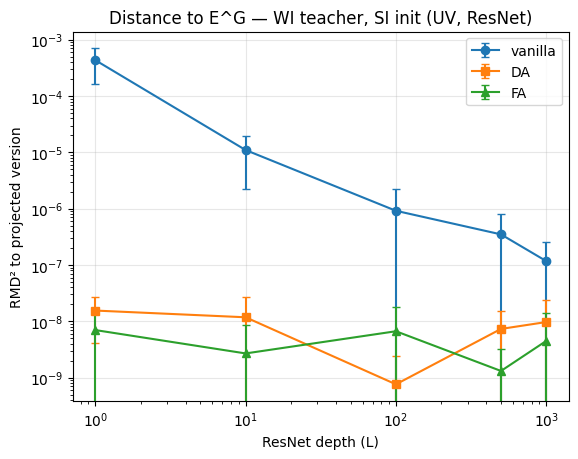

In [7]:
plot_rmd_curves(L_VALUES, results_wi, "ResNet depth (L)", "Distance to E^G — WI teacher, SI init (UV, ResNet)", exclude=["EA"])


## 2. Distance to $E^G$ — arbitrary teacher, SI init

In [14]:
teacher_arb = make_arbitrary_particles_resnet(1)

results_arb = {"vanilla": [], "DA": [], "FA": [], "EA": []}

for L in L_VALUES:
    for name in results_arb:
        results_arb[name].append([])

    for rep in range(N_REPS):
        key = jax.random.PRNGKey(rep * 1000 + N)

        h = train_resnet(teacher_arb, N, L, jax.random.fold_in(key, 0), CONFIG, "si")
        results_arb["vanilla"][-1].append(rmd_to_projected(h["particles"][-1][0]))

        h = train_resnet(teacher_arb, N, L, jax.random.fold_in(key, 1), CONFIG, "si", used_loss_fn=loss_fn_da_resnet)
        results_arb["DA"][-1].append(rmd_to_projected(h["particles"][-1][0]))

        h = train_resnet(teacher_arb, N, L, jax.random.fold_in(key, 2), CONFIG, "si", used_loss_fn=loss_fn_fa_resnet)
        results_arb["FA"][-1].append(rmd_to_projected(h["particles"][-1][0]))

        # h = train_resnet(teacher_arb, N, L, jax.random.fold_in(key, 3), CONFIG, "si", used_loss_fn=loss_fn_ea_resnet)
        # results_arb["EA"][-1].append(rmd_to_projected(h["particles"][-1][0]))

    print(f"L={L} done")


L=1 done
L=10 done
L=100 done


KeyboardInterrupt: 

In [ ]:
plot_rmd_curves(L_VALUES, results_arb, "ResNet depth (L)", "Distance to E^G — arbitrary teacher, SI init (UV, ResNet)")


## 3. Equivariance check — WI teacher

In [3]:
teacher = make_wi_particles_resnet(1)
N = 5
L = 100
key = jax.random.PRNGKey(42)

configs = {**DEFAULT_CONFIG_RESNET, "T": 2.0, "gr": 10}
configs['beta'] = 0.

h_vanilla = train_resnet(teacher, N, L, jax.random.fold_in(key, 0), configs, "si")
print("vanilla done")
# h_da = train_resnet(teacher, N, L, jax.random.fold_in(key, 1), configs, "si", used_loss_fn=loss_fn_da_resnet)
# print("DA done")
# h_fa = train_resnet(teacher, N, L, jax.random.fold_in(key, 2), configs, "si", used_loss_fn=loss_fn_fa_resnet)
# print("FA done")
# h_ea = train_resnet(teacher, N, L, jax.random.fold_in(key, 3), configs, "si", used_loss_fn=loss_fn_ea_resnet)
# print("EA done")


W0424 16:19:31.147049  640661 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


vanilla done


In [6]:
fig = plot_uv_equivariance_resnet(h_vanilla["particles"][-1], teacher, title="Student vs teacher — vanilla (ResNet, UV)")

In [4]:
fig.write_image('Resnet_uv_vanilla_WI.pdf', scale=3)

In [24]:
pio.write_html(fig, 'Resnet_uv_vanilla_WI.html')

In [6]:
fig = plot_uv_equivariance_resnet(h_da["particles"][-1], teacher, title="Student vs teacher — DA (ResNet, UV)")


NameError: name 'h_da' is not defined

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [32]:
pio.write_html(fig, 'Resnet_uv_DA_WI.html')

In [33]:
fig = plot_uv_equivariance_resnet(h_fa["particles"][-1], teacher, title="Student vs teacher — FA (ResNet, UV)")


In [34]:
pio.write_html(fig, 'Resnet_uv_FA_WI.html')

In [35]:
fig = plot_uv_equivariance_resnet(h_ea["particles"][-1], teacher, title="Student vs teacher — EA (ResNet, UV)")


In [36]:
pio.write_html(fig, 'Resnet_uv_EA_WI.html')

## 4. Equivariance check — arbitrary teacher

In [ ]:
teacher_arb2 = make_arbitrary_particles_resnet(1)

N = 5
L = 100
key = jax.random.PRNGKey(42)

configs = {**DEFAULT_CONFIG_RESNET, "T": 2.0, "gr": 10}
configs['beta'] = 0.

h_vanilla_arb = train_resnet(teacher_arb2, N, L, jax.random.fold_in(key, 0), configs, "si")
print("vanilla done")
h_da_arb = train_resnet(teacher_arb2, N, L, jax.random.fold_in(key, 1), configs, "si", used_loss_fn=loss_fn_da_resnet)
print("DA done")
h_fa_arb = train_resnet(teacher_arb2, N, L, jax.random.fold_in(key, 2), configs, "si", used_loss_fn=loss_fn_fa_resnet)
print("FA done")
h_ea_arb = train_resnet(teacher_arb2, N, L, jax.random.fold_in(key, 3), configs, "si", used_loss_fn=loss_fn_ea_resnet)
print("EA done")


vanilla done
DA done
FA done
EA done


In [12]:
plot_uv_equivariance_resnet(h_vanilla_arb["particles"][-1], teacher_arb2, title="Arbitrary teacher — vanilla (ResNet, UV)")


In [13]:
plot_uv_equivariance_resnet(h_da_arb["particles"][-1], teacher_arb2, title="Arbitrary teacher — DA (ResNet, UV)")


In [ ]:
plot_uv_equivariance_resnet(h_fa_arb["particles"][-1], teacher_arb2, title="Arbitrary teacher — FA (ResNet, UV)")


In [ ]:
plot_uv_equivariance_resnet(h_ea_arb["particles"][-1], teacher_arb2, title="Arbitrary teacher — EA (ResNet, UV)")
